# Ayudantía 9

**Problema:** Reactor de polimerización batch. Se quiere **maximizar la conversión de monómero (%)** estudiando 3 factores a 2 niveles con **$n = 2$ réplicas** por tratamiento ($2^3 \times 2 = 16$ corridas totales).

| Factor | Variable | Nivel bajo $(-1)$ | Nivel alto $(+1)$ |
|--------|----------|-------------------|-------------------|
| $A$ | Temperatura del reactor | 120 °C | 160 °C |
| $B$ | Concentración de iniciador | 0.5 % w/w | 2.0 % w/w |
| $C$ | Tiempo de reacción | 2 h | 6 h |

## 0. Librerías

In [31]:
from pydoe import ff2n                   # generación de matrices de diseño factorial
import numpy as np                         # álgebra lineal y operaciones numéricas
import pandas as pd                        # manejo de DataFrames
import matplotlib.pyplot as plt            # visualización
import itertools                           # combinaciones para la matriz de contrastes
import statsmodels.api as sm               # modelado estadístico
from statsmodels.formula.api import ols    # regresión por fórmula (estilo R)
from statsmodels.stats.diagnostic import het_breuschpagan  # prueba de heterocedasticidad
import scipy.stats                         # distribuciones y pruebas estadísticas
import sklearn.preprocessing as skp        # codificación min-max

## 1. Datos y Codificación de Factores

### 1.1 ¿Por qué codificar?

Los factores se transforman a escala codificada $x_j \in \{-1, +1\}$ mediante:

$$
x_{\text{cod}} = \frac{x - \dfrac{x_{\max}+x_{\min}}{2}}{\dfrac{x_{\max}-x_{\min}}{2}}
$$

Esta transformación tiene dos ventajas fundamentales:

1. **Ortogonalidad:** la matriz de diseño $\mathbf{X}$ satisface $\mathbf{X}'\mathbf{X} = n \cdot 2^k \mathbf{I}$, lo que hace que todos los estimadores de efectos sean **independientes entre sí** y comparables en magnitud.
2. **Interpretabilidad:** el efecto estimado $\hat{E}_j$ mide el cambio en la respuesta al pasar de $-1$ a $+1$ (rango completo del factor).

In [32]:
# ── Datos experimentales ──────────────────────────────────────────────────────
A = [120, 160, 120, 160, 120, 160, 120, 160]   # temperatura (°C)
B = [0.5, 0.5, 2.0, 2.0, 0.5, 0.5, 2.0, 2.0]  # conc. iniciador (% w/w)
C = [2,   2,   2,   2,   6,   6,   6,   6  ]   # tiempo de reacción (h)
Y1 = [38, 50, 42, 54, 48, 76, 52, 79]           # réplica 1
Y2 = [41, 52, 40, 52, 51, 79, 50, 78]           # réplica 2

data = pd.DataFrame({'A': A, 'B': B, 'C': C, 'Y1': Y1, 'Y2': Y2})

# ── Codificación min-max a {-1, +1} ──────────────────────────────────────────
data_coded = data.copy()
for col in ['A', 'B', 'C']:
    data_coded[col] = skp.minmax_scale(data[col], feature_range=(-1, 1)).round(4)

data_coded

,A,B,C,Y1,Y2
0,-1.0,-1.0,-1.0,38,41
1,1.0,-1.0,-1.0,50,52
2,-1.0,1.0,-1.0,42,40
3,1.0,1.0,-1.0,54,52
4,-1.0,-1.0,1.0,48,51
5,1.0,-1.0,1.0,76,79
6,-1.0,1.0,1.0,52,50
7,1.0,1.0,1.0,79,78


## 2. Matriz de Contrastes de Yates y Estimación de Efectos

### Método de los contrastes

Para un diseño $2^k$ con $n$ réplicas, el efecto de cada factor/interacción se estima como:

$$\hat{E}_j = \frac{\text{Contraste}_j}{n \cdot 2^{k-1}}$$

donde el contraste es la combinación lineal de los **totales** por tratamiento $T_i$:

$$\text{Contraste}_j = \sum_{i=1}^{2^k} c_{ij} \cdot T_i, \qquad c_{ij} \in \{-1, +1\}$$

Los signos $c_{ij}$ forman la **matriz de contrastes ortogonal de Yates**: cada columna corresponde a un efecto, cada fila a un tratamiento.

### Relación con modelos lineales

Gracias a la ortogonalidad ($\mathbf{X}'\mathbf{X} = n \cdot 2^k \mathbf{I}$), los coeficientes del modelo OLS son:

$$\hat{\beta}_j = \frac{\text{Contraste}_j}{n \cdot 2^k} = \frac{\hat{E}_j}{2}$$

Es decir, **el coeficiente OLS es la mitad del efecto completo**, porque $\beta_j$ mide el cambio por unidad codificada, mientras que $\hat{E}_j$ mide el cambio de $-1$ a $+1$ (2 unidades).

In [33]:
# ── Funciones auxiliares ──────────────────────────────────────────────────────

def get_codification(df, factor_names):
    """Asigna el código de tratamiento estándar a cada fila (ej: '(1)', '(a)', '(ab)')."""
    codes = []
    for idx in range(len(df)):
        row = df.iloc[idx]
        if all(row[f] == -1 for f in factor_names):
            codes.append('(1)')
        else:
            code = '(' + ''.join(f for f in factor_names if row[f] == 1) + ')'
            codes.append(code)
    return codes


def generar_matriz_contraste(factores):
    """
    Genera la matriz de contraste ortogonal para un diseño 2^k en orden de Yates.
    Columnas: intercepto, efectos principales, todas las interacciones.
    Filas: 2^k tratamientos.
    """
    k = len(factores)
    niveles = list(itertools.product([-1, 1], repeat=k))
    df = pd.DataFrame(niveles, columns=factores)
    df['(Intercept)'] = 1
    for r in range(2, k + 1):
        for comb in itertools.combinations(factores, r):
            df[''.join(comb)] = df[list(comb)].prod(axis=1)
    cols = ['(Intercept)'] + factores + [
        ''.join(comb) for r in range(2, k+1)
        for comb in itertools.combinations(factores, r)
    ]
    etiquetas = [
        '(' + ''.join(factores[i] for i, v in enumerate(nivel) if v == 1) + ')' or '(1)'
        for nivel in niveles
    ]
    etiquetas = [e if e != '()' else '(1)' for e in etiquetas]
    df.index = pd.Index(etiquetas, name='Tratamiento')
    return df[cols], cols

# ── Preparar DataFrame con réplicas separadas ─────────────────────────────────
rep1 = data_coded[['A','B','C','Y1']].copy().rename(columns={'Y1': 'Response'})
rep1['Replicate'] = 1
rep2 = data_coded[['A','B','C','Y2']].copy().rename(columns={'Y2': 'Response'})
rep2['Replicate'] = 2
df_2k_coded = pd.concat([rep1, rep2], ignore_index=True)
df_2k_coded['Codification'] = get_codification(df_2k_coded, ['A','B','C'])

# ── Calcular efectos vía contrastes de Yates ----------------------------------
matrix_contraste, cols = generar_matriz_contraste(['A','B','C'])
totales = df_2k_coded.groupby('Codification')['Response'].sum()
totales = totales.loc[matrix_contraste.index].values

n_rep = df_2k_coded['Replicate'].nunique()   # n = 2 réplicas
k     = len(['A','B','C'])                   # k = 3 factores

normalizacion = n_rep * 2**(k - 1)
efectos = (matrix_contraste.T @ totales) / normalizacion

efectos

(Intercept)    110.25
A               19.75
B                1.50
C               18.00
AB               0.00
AC               8.00
BC              -0.25
ABC             -0.25
dtype: float64

## 3. Modelo OLS Completo $2^3$

Ajustamos el modelo completo de regresión:

$$y = \beta_0 + \beta_A x_A + \beta_B x_B + \beta_C x_C + \beta_{AB} x_A x_B + \beta_{AC} x_A x_C + \beta_{BC} x_B x_C + \beta_{ABC} x_A x_B x_C + \varepsilon$$

con $\varepsilon \sim \mathcal{N}(0, \sigma^2)$. El modelo tiene $2^3 = 8$ parámetros y $16 - 8 = 8$ grados de libertad para el error, que corresponden únicamente a la **variabilidad intra-tratamiento** (entre réplicas).


In [34]:
modelo = ols('Response ~ A * B * C', data=df_2k_coded).fit()
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:               Response   R-squared:                       0.993
Model:                            OLS   Adj. R-squared:                  0.987
Method:                 Least Squares   F-statistic:                     162.2
Date:                Wed, 13 May 2026   Prob (F-statistic):           5.55e-08
Time:                        17:17:25   Log-Likelihood:                -25.251
No. Observations:                  16   AIC:                             66.50
Df Residuals:                       8   BIC:                             72.68
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     55.1250      0.415    132.967      0.0

Notemos que, efectivamente, $\beta_i = \frac{\hat{E}_i}{2}$

## 4. ANOVA Tipo II

### ¿Por qué Tipo II?

El **ANOVA Tipo I** asigna la SS de cada efecto secuencialmente (el orden de entrada importa). El **ANOVA Tipo II** asigna la SS de cada efecto ajustando por *todos los demás* efectos de su orden o menor — es invariante al orden de entrada.

### Fórmula de la SS por efecto

Para cada efecto $j$ en un diseño $2^k$ balanceado:

$$SS_j = \frac{(\text{Contraste}_j)^2}{n \cdot 2^k}$$

Cada efecto tiene exactamente **1 grado de libertad**, por lo que $MS_j = SS_j$.

El estadístico de prueba es:

$$F_j = \frac{MS_j}{MS_E} \sim F(1,\, \nu_E) \quad \text{bajo } H_0: E_j = 0$$

con $\nu_E = n \cdot 2^k - 2^k = 2^k(n-1) = 8$ grados de libertad para el error.

In [35]:
anova_completo = sm.stats.anova_lm(modelo, typ=2)

print(anova_completo.round(4))

           sum_sq   df         F  PR(>F)
A         1560.25  1.0  567.3636  0.0000
B            9.00  1.0    3.2727  0.1080
A:B          0.00  1.0    0.0000  1.0000
C         1296.00  1.0  471.2727  0.0000
A:C        256.00  1.0   93.0909  0.0000
B:C          0.25  1.0    0.0909  0.7707
A:B:C        0.25  1.0    0.0909  0.7707
Residual    22.00  8.0       NaN     NaN


## 5. Verificación de Supuestos del Modelo

El modelo de regresión asume que los residuales $e_i = y_i - \hat{y}_i$ son:

1. **Normales:** se evalúa con el gráfico Q-Q (puntos sobre la línea diagonal) y la prueba de Shapiro-Wilk ($p > 0.05$ indica normalidad).
2. **Homocedásticos** (varianza constante): el gráfico residuales vs. valores ajustados no debe mostrar patrones en forma de embudo.
3. **Independientes:** se garantiza por la aleatorización del experimento.



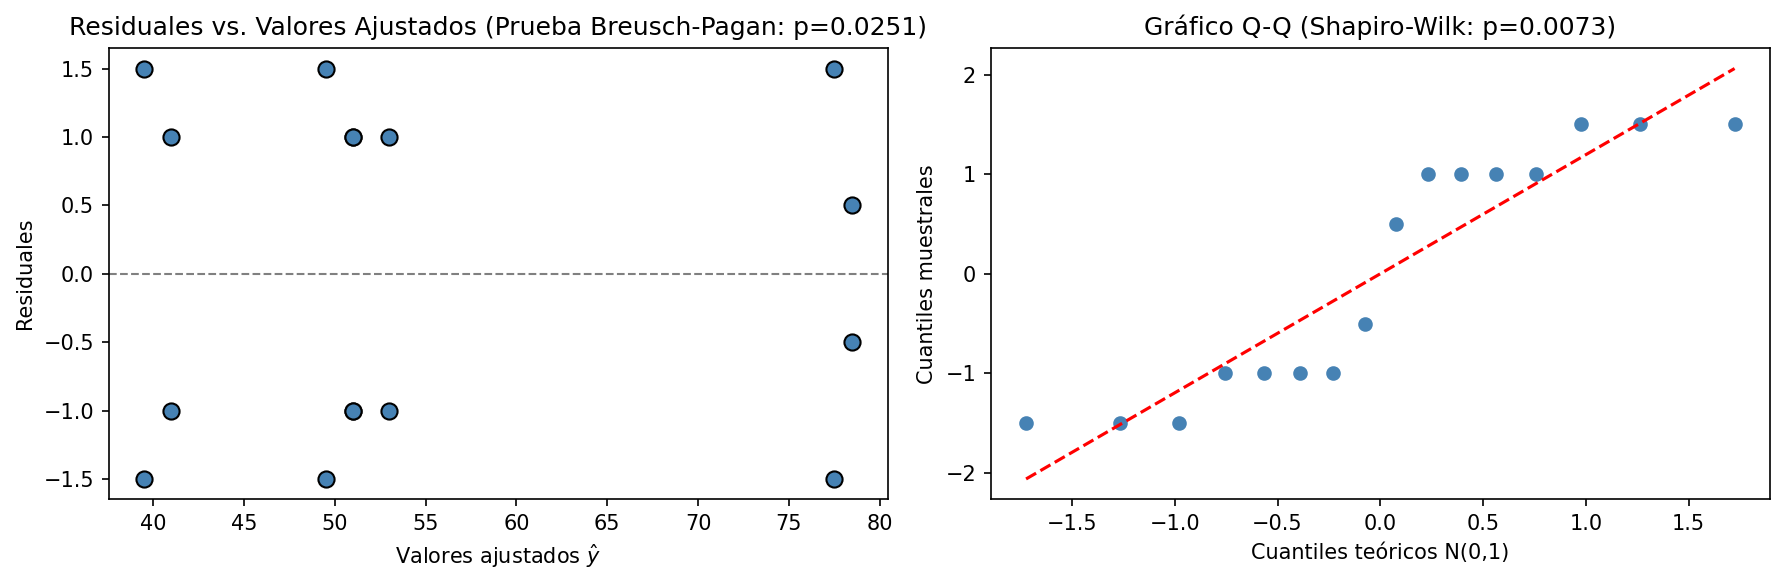

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), dpi=150)

# ── Residuales vs. Valores Ajustados ─────────────────────────────────────────
axes[0].scatter(modelo.fittedvalues, modelo.resid, color='steelblue', edgecolors='k', s=60)
axes[0].axhline(0, color='gray', linestyle='--', linewidth=1)
axes[0].set_xlabel('Valores ajustados $\\hat{y}$')
axes[0].set_ylabel('Residuales')
bp = het_breuschpagan(modelo.resid, modelo.model.exog)
axes[0].set_title(f'Residuales vs. Valores Ajustados (Prueba Breusch-Pagan: p={bp[1]:.4f})')

# ── Gráfico Q-Q ───────────────────────────────────────────────────────────────
(osm, osr), (slope, intercept, _) = scipy.stats.probplot(modelo.resid, dist='norm')
axes[1].plot(osm, osr, 'o', color='steelblue', markersize=6)
axes[1].plot(osm, slope * np.array(osm) + intercept, 'r--', linewidth=1.5)
axes[1].set_xlabel('Cuantiles teóricos N(0,1)')
axes[1].set_ylabel('Cuantiles muestrales')
axes[1].set_title(f'Gráfico Q-Q (Shapiro-Wilk: p={scipy.stats.shapiro(modelo.resid)[1]:.4f})')

plt.tight_layout()
plt.show()


## 6. Intervalos de Confianza para los Efectos

Para un diseño $2^k$ con $n$ réplicas, el **error estándar del efecto estimado** es:

$$SE(\hat{E}_j) = \frac{2\sqrt{MS_E}}{\sqrt{n \cdot 2^k}}$$

El factor 2 proviene de que el efecto mide el cambio en 2 unidades codificadas (de $-1$ a $+1$).

El intervalo de confianza al $100(1-\alpha)$% es:

$$IC_{1-\alpha}(\hat{E}_j) = \hat{E}_j \pm t_{\alpha/2,\, \nu_E} \cdot SE(\hat{E}_j)$$

**Regla de decisión:** si el IC **excluye el cero**, el efecto es significativo — equivalente al test F del ANOVA con el mismo $\alpha$.

> **Ojo:** `modelo.params` contiene $\hat{\beta}_j = \hat{E}_j / 2$. Las fórmulas de abajo convierten correctamente a la escala de **efectos completos** $\hat{E}_j$ multiplicando los params por 2, o equivalentemente computando la SE a partir de los contrastes.

,Efecto,IC inferior,IC superior
Intercept,55.125,53.213,57.037
A,19.750,17.838,21.662
B,1.500,-0.412,3.412
A:B,0.000,-1.912,1.912
C,18.000,16.088,19.912
A:C,8.000,6.088,9.912
B:C,-0.250,-2.162,1.662
A:B:C,-0.250,-2.162,1.662


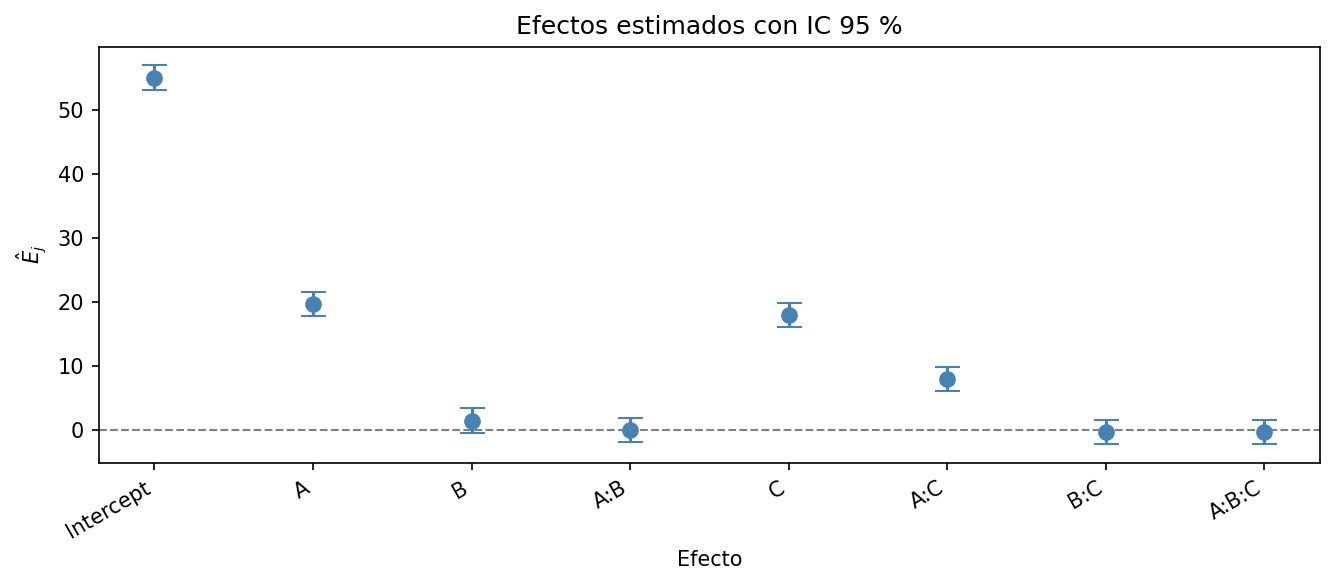

In [37]:
n_rep = df_2k_coded['Replicate'].nunique()   # n = 2
k = len(['A', 'B', 'C'])                  # k = 3
 
# SE del efecto: 2*sqrt(MSE) / sqrt(n * 2^k)
se = 2 * np.sqrt(modelo.mse_resid) / np.sqrt(n_rep * 2**k)

# Valor crítico t con nu_E = df_resid grados de libertad
t_crit = scipy.stats.t.ppf(1 - 0.05/2, df=modelo.df_resid)
margen  = t_crit * se

# Los efectos completos son 2 * beta_hat (excepto el intercepto)
efectos_ols = modelo.params.copy()
efectos_ols[1:] = 2 * efectos_ols[1:]   # convertir beta -> efecto

ci_df = pd.DataFrame({
    'Efecto': efectos_ols,
    'IC inferior':          efectos_ols - margen,
    'IC superior':          efectos_ols + margen,
})
display(ci_df.round(4))

# ── Gráfico de coeficientes ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4), dpi=150)
labels = list(efectos_ols.index)
vals   = efectos_ols.values
ax.errorbar(labels, vals, yerr=margen, fmt='o', capsize=6,
            color='steelblue', ecolor='steelblue', linewidth=1.5, markersize=7)
ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('Efecto')
ax.set_ylabel('$\\hat{E}_j$')
ax.set_title('Efectos estimados con IC 95 %')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 7. Gráfico de Interacción $A \times C$

El gráfico de interacción representa la **respuesta media** en función de un factor (eje $x$), con una línea por cada nivel del otro factor.


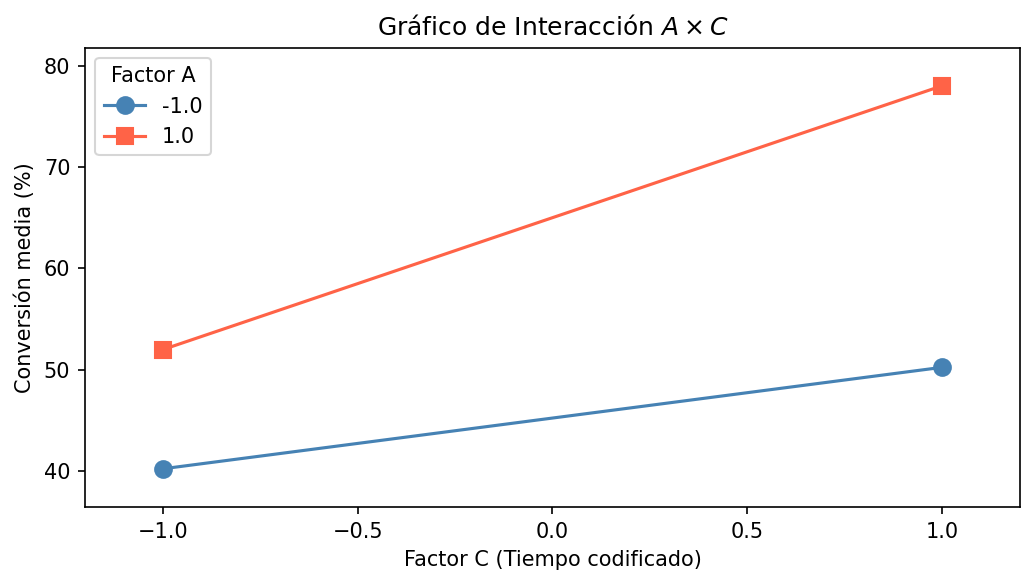

In [38]:
fig, ax = plt.subplots(figsize=(7, 4), dpi=150)
sm.graphics.interaction_plot(
    x=df_2k_coded['C'],
    trace=df_2k_coded['A'],
    response=df_2k_coded['Response'],
    colors=['steelblue', 'tomato'],
    markers=['o', 's'],
    ms=8, ax=ax
)
ax.set_xlabel('Factor C (Tiempo codificado)')
ax.set_ylabel('Conversión media (%)')
ax.set_title('Gráfico de Interacción $A \\times C$')
ax.legend(title='Factor A')
plt.tight_layout()
plt.show()

## 8. Modelo Reducido: $A + C + A:C$

Los efectos no significativos ($B$, $AB$, $BC$, $ABC$) se **fusionan al error**, ganando grados de libertad:

| Modelo | Parámetros | $\nu_E$ (df error) | Ventaja |
|--------|:----------:|:-------------------:|---------|
| Completo ($A*B*C$) | 8 | 8 | Ningún supuesto |
| Reducido ($A+C+A:C$) | 4 | **12** | Mayor potencia, IC más estrechos |

El $MS_E$ del modelo reducido absorbe la variabilidad de los efectos nulos: $SS_E^{\text{red}} = SS_B + SS_{AB} + SS_{BC} + SS_{ABC} + SS_E^{\text{puro}}$.

Si la interacción $A:C$ se incluye, los efectos principales $A$ y $C$ deben permanecer en el modelo aunque no fueran individualmente significativos.

El modelo reducido es:
$$\hat{y} = \hat{\beta}_0 + \hat{\beta}_A\, x_A + \hat{\beta}_C\, x_C + \hat{\beta}_{AC}\, x_A x_C$$

In [39]:
modelo_red = ols('Response ~ A + C + A:C', data=df_2k_coded).fit()
print(modelo_red.summary())

                            OLS Regression Results                            
Dep. Variable:               Response   R-squared:                       0.990
Model:                            OLS   Adj. R-squared:                  0.987
Method:                 Least Squares   F-statistic:                     395.2
Date:                Wed, 13 May 2026   Prob (F-statistic):           2.96e-12
Time:                        17:17:26   Log-Likelihood:                -28.122
No. Observations:                  16   AIC:                             64.24
Df Residuals:                      12   BIC:                             67.33
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     55.1250      0.405    136.096      0.0

### 8.1 ANOVA del Modelo Reducido

Con $\nu_E = 12$ grados de libertad (vs. 8 del modelo completo), el $MS_E$ se estima con más precisión y los valores $p$ son más confiables.

In [40]:
anova_red = sm.stats.anova_lm(modelo_red, typ=2)
print("ANOVA Tipo II — Modelo Reducido:")
print(anova_red.round(4))

ANOVA Tipo II — Modelo Reducido:
           sum_sq    df         F  PR(>F)
A         1560.25   1.0  594.3810     0.0
C         1296.00   1.0  493.7143     0.0
A:C        256.00   1.0   97.5238     0.0
Residual    31.50  12.0       NaN     NaN


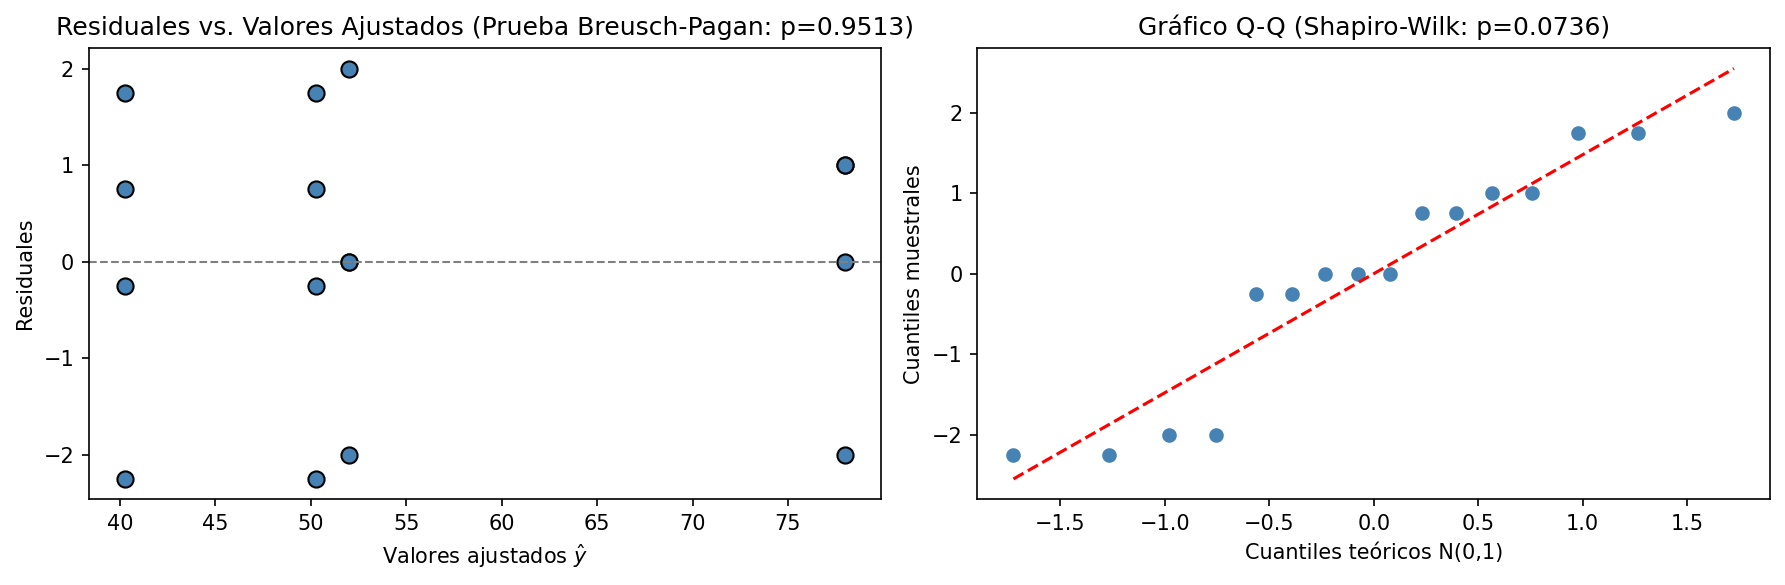

In [41]:
# verificamos los supuestos
fig, axes = plt.subplots(1, 2, figsize=(12, 4), dpi=150)

# ── Residuales vs. Valores Ajustados ─────────────────────────────────────────
axes[0].scatter(modelo_red.fittedvalues, modelo_red.resid, color='steelblue', edgecolors='k', s=60)
axes[0].axhline(0, color='gray', linestyle='--', linewidth=1)
axes[0].set_xlabel('Valores ajustados $\\hat{y}$')
axes[0].set_ylabel('Residuales')
bp = het_breuschpagan(modelo_red.resid, modelo_red.model.exog)
axes[0].set_title(f'Residuales vs. Valores Ajustados (Prueba Breusch-Pagan: p={bp[1]:.4f})')

# ── Gráfico Q-Q ───────────────────────────────────────────────────────────────
(osm, osr), (slope, intercept, _) = scipy.stats.probplot(modelo_red.resid, dist='norm')
axes[1].plot(osm, osr, 'o', color='steelblue', markersize=6)
axes[1].plot(osm, slope * np.array(osm) + intercept, 'r--', linewidth=1.5)
axes[1].set_xlabel('Cuantiles teóricos N(0,1)')
axes[1].set_ylabel('Cuantiles muestrales')
axes[1].set_title(f'Gráfico Q-Q (Shapiro-Wilk: p={scipy.stats.shapiro(modelo_red.resid)[1]:.4f})')

plt.tight_layout()
plt.show()


### 8.2 Intervalos de Confianza — Modelo Reducido

El diseño original sigue siendo $2^3$ con $n=2$ réplicas, por lo que la fórmula de $SE(\hat{E}_j)$ usa $k=3$ y $n=2$. Lo que cambia es el $MS_E$ (ahora mayor) y los **grados de libertad** del t crítico ($\nu_E = 12$ en lugar de 8).

,Efecto,IC inferior,IC superior
Intercept,55.125,53.360,56.890
A,19.750,17.985,21.515
C,18.000,16.235,19.765
A:C,8.000,6.235,9.765


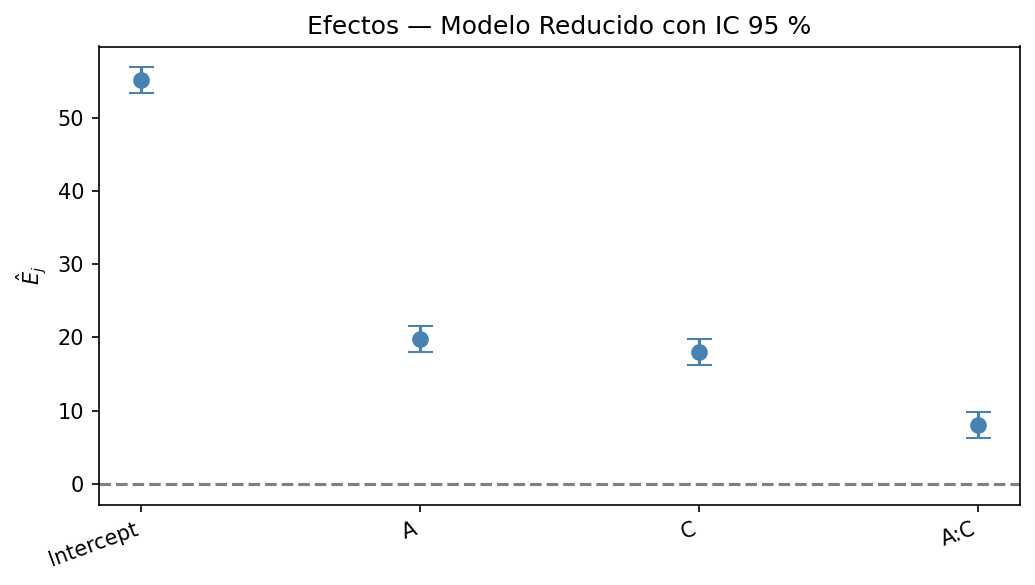

In [42]:
n_rep = df_2k_coded['Replicate'].nunique()   # n = 2
k = 3                                      # diseño original 2^3

se_red  = 2 * np.sqrt(modelo_red.mse_resid) / np.sqrt(n_rep * 2**k)
t_crit  = scipy.stats.t.ppf(1 - 0.05/2, df=modelo_red.df_resid)
margen  = t_crit * se_red

efectos_red = modelo_red.params.copy()
efectos_red[1:] *= 2   # beta -> efecto completo

ci_red = pd.DataFrame({
    'Efecto': efectos_red,
    'IC inferior':          efectos_red - margen,
    'IC superior':          efectos_red + margen,
})
display(ci_red.round(4))

fig, ax = plt.subplots(figsize=(7, 4), dpi=150)
ax.errorbar(list(efectos_red.index), efectos_red.values, yerr=margen,
            fmt='o', capsize=6, color='steelblue', markersize=7)
ax.axhline(0, color='gray', linestyle='--')
ax.set_ylabel('$\\hat{E}_j$')
ax.set_title('Efectos — Modelo Reducido con IC 95 %')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

## 9. Superficie de Respuesta

El modelo reducido define una **función bilineal** en el espacio codificado $[-1,+1]^2$:

$$\hat{y}(x_A, x_C) = \hat{\beta}_0 + \hat{\beta}_A x_A + \hat{\beta}_C x_C + \hat{\beta}_{AC} x_A x_C$$

El gráfico de contornos ("isolíneas") muestra las combinaciones $(x_A, x_C)$ que producen la misma conversión predicha.


**Lectura del gráfico:** la región de mayor conversión (colores más claros / valores más altos) se ubica en $x_A \to +1$ (160 °C) y $x_C \to +1$ (6 h), confirmando la interacción sinérgica $A \times C$.

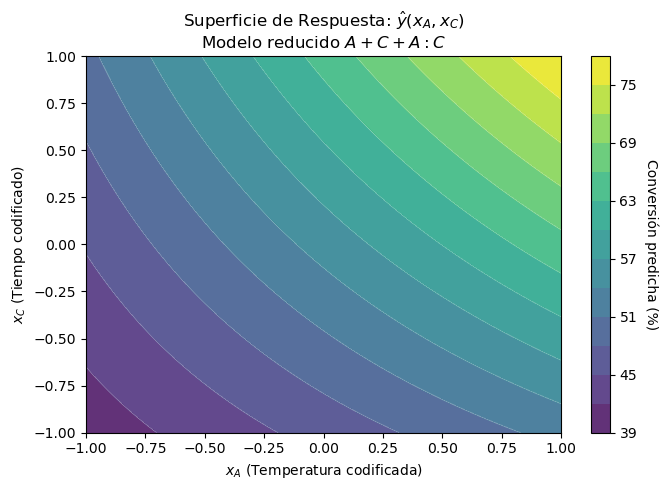

Modelo reducido: y_modelo = 55.13 + 9.87 x_A + 9.00 x_C + 4.00x_A x_C$


In [43]:
# Malla 100×100 en el espacio codificado
a_grid = np.linspace(-1, 1, 100)
c_grid = np.linspace(-1, 1, 100)
A_mesh, C_mesh = np.meshgrid(a_grid, c_grid)

b0  = modelo_red.params['Intercept']
bA  = modelo_red.params['A']
bC  = modelo_red.params['C']
bAC = modelo_red.params['A:C']

Y_hat = b0 + bA * A_mesh + bC * C_mesh + bAC * A_mesh * C_mesh

fig, ax = plt.subplots(figsize=(7, 5), dpi=100)
cs   = ax.contourf(A_mesh, C_mesh, Y_hat, levels=12, cmap='viridis', alpha=0.85)
ctrl = ax.contour(A_mesh, C_mesh, Y_hat,  levels=12, colors='white', linewidths=0.5, alpha=0.5)
cbar = fig.colorbar(cs, ax=ax)
cbar.set_label('Conversión predicha (%)', rotation=270, labelpad=15)
ax.set_xlabel('$x_A$ (Temperatura codificada)')
ax.set_ylabel('$x_C$ (Tiempo codificado)')
ax.set_title('Superficie de Respuesta: $\\hat{y}(x_A, x_C)$\nModelo reducido $A + C + A{:}C$')

# ax.legend(loc='lower left', fontsize=8)
plt.tight_layout()
plt.show()

print(f"Modelo reducido: y_modelo = {b0:.2f} + {bA:.2f} x_A + {bC:.2f} x_C + {bAC:.2f}x_A x_C$")
